<a href="https://colab.research.google.com/github/reneta-dimitrova96/Deep-Learning-Course-Project-2026/blob/main/notebooks/04_pretrained_language_model_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pretrained Language Model Fine-Tuning with DistilBERT

## Notebook Objective

In this notebook, a pretrained DistilBERT model is fine-tuned for the paraphrase detection task.

The two sentences are processed together by the model to predict whether they have the same meaning.

DistilBERT was selected because it provides contextual language representations while being smaller and faster than BERT, making it a practical choice for fine-tuning with limited computational resources.

The project uses the **PAWS-Wiki Labeled (Final)** dataset. The PAWS-Wiki dataset was released by Google Research and is used in this project for educational purposes. Google LLC (Google) is acknowledged as the data source.

### Sources

- [PAWS-Wiki Dataset on Hugging Face](https://huggingface.co/datasets/google-research-datasets/paws)
- [Official PAWS Repository by Google Research](https://github.com/google-research-datasets/paws)
- [PAWS: Paraphrase Adversaries from Word Scrambling](https://arxiv.org/abs/1904.01130)
- [DistilBERT Base Uncased on Hugging Face](https://huggingface.co/distilbert/distilbert-base-uncased)
- [DistilBERT Paper](https://arxiv.org/abs/1910.01108)
- [Hugging Face Transformers Documentation](https://huggingface.co/docs/transformers/index)

## 1. Setup and Imports

The required libraries are imported for loading the dataset, preprocessing the sentence pairs, fine-tuning DistilBERT and evaluating the model.

In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
import numpy as np
import os
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from transformers import set_seed

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

USE_FP16 = torch.cuda.is_available()

GPU available: True
GPU: Tesla T4


## 2. Data Loading and Cleaning

The same PAWS-Wiki dataset and cleaning process from the previous notebooks are used to keep the data consistent across the different models.

In [ ]:
dataset = load_dataset(
    "google-research-datasets/paws",
    "labeled_final"
)

README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 8.43MB            

labeled_final/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

labeled_final/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 1.24MB            

labeled_final/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

labeled_final/validation-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B / 1.23MB            

labeled_final/validation-00000-of-00001.(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [ ]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

### Data Cleaning

The same cleaning function is used to remove sentence pairs with conflicting labels and keep only one occurrence of the remaining duplicates.

In [ ]:
def clean_sentence_pairs(df):
    pair_columns = ["sentence1", "sentence2"]

    conflicting_pairs = (
        df.groupby(pair_columns)["label"]
        .nunique()
        .reset_index()
    )

    conflicting_pairs = conflicting_pairs[
        conflicting_pairs["label"] > 1
    ]

    clean_df = df.merge(
        conflicting_pairs[pair_columns],
        on=pair_columns,
        how="left",
        indicator=True
    )

    clean_df = clean_df[
        clean_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    clean_df = clean_df.drop_duplicates(
        subset=pair_columns
    ).reset_index(drop=True)

    return clean_df

In [ ]:
clean_train_df = clean_sentence_pairs(train_df)
clean_validation_df = clean_sentence_pairs(validation_df)
clean_test_df = clean_sentence_pairs(test_df)

print("Train:", clean_train_df.shape)
print("Validation:", clean_validation_df.shape)
print("Test:", clean_test_df.shape)

Train: (49334, 4)
Validation: (7994, 4)
Test: (7977, 4)


## 3. Tokenization

The pretrained DistilBERT tokenizer is used to convert the sentence pairs into numerical inputs for the model.

Both sentences are passed to the tokenizer together so that the model can process them as a single pair.
A maximum sequence length of 128 tokens is used because the sentence pairs are relatively short and this length is sufficient for the tokenized inputs.

In [ ]:
MODEL_NAME = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
example_sentence1 = clean_train_df["sentence1"].iloc[0]
example_sentence2 = clean_train_df["sentence2"].iloc[0]

example_encoding = tokenizer(
    example_sentence1,
    example_sentence2,
    truncation=True,
    max_length=128
)

print("Sentence 1:")
print(example_sentence1)

print("\nSentence 2:")
print(example_sentence2)

print("\nInput IDs:")
print(example_encoding["input_ids"])

print("\nAttention Mask:")
print(example_encoding["attention_mask"])

Sentence 1:
In Paris , in October 1560 , he secretly met the English ambassador , Nicolas Throckmorton , asking him for a passport to return to England through Scotland .

Sentence 2:
In October 1560 , he secretly met with the English ambassador , Nicolas Throckmorton , in Paris , and asked him for a passport to return to Scotland through England .

Input IDs:
[101, 1999, 3000, 1010, 1999, 2255, 29185, 1010, 2002, 10082, 2777, 1996, 2394, 6059, 1010, 9473, 16215, 16901, 5302, 11715, 1010, 4851, 2032, 2005, 1037, 12293, 2000, 2709, 2000, 2563, 2083, 3885, 1012, 102, 1999, 2255, 29185, 1010, 2002, 10082, 2777, 2007, 1996, 2394, 6059, 1010, 9473, 16215, 16901, 5302, 11715, 1010, 1999, 3000, 1010, 1998, 2356, 2032, 2005, 1037, 12293, 2000, 2709, 2000, 3885, 2083, 2563, 1012, 102]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [ ]:
print(
    tokenizer.convert_ids_to_tokens(
        example_encoding["input_ids"]
    )
)

['[CLS]', 'in', 'paris', ',', 'in', 'october', '1560', ',', 'he', 'secretly', 'met', 'the', 'english', 'ambassador', ',', 'nicolas', 'th', '##rock', '##mo', '##rton', ',', 'asking', 'him', 'for', 'a', 'passport', 'to', 'return', 'to', 'england', 'through', 'scotland', '.', '[SEP]', 'in', 'october', '1560', ',', 'he', 'secretly', 'met', 'with', 'the', 'english', 'ambassador', ',', 'nicolas', 'th', '##rock', '##mo', '##rton', ',', 'in', 'paris', ',', 'and', 'asked', 'him', 'for', 'a', 'passport', 'to', 'return', 'to', 'scotland', 'through', 'england', '.', '[SEP]']


### Tokenizing the Dataset

The same tokenizer is applied to all sentence pairs in the training, validation and test sets. Padding and truncation are used so that the inputs have the same maximum length.

In [ ]:
def tokenize_sentence_pairs(df):
    return tokenizer(
        df["sentence1"].tolist(),
        df["sentence2"].tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

In [ ]:
train_encodings = tokenize_sentence_pairs(
    clean_train_df
)

validation_encodings = tokenize_sentence_pairs(
    clean_validation_df
)

test_encodings = tokenize_sentence_pairs(
    clean_test_df
)

In [ ]:
print(
    "Train:",
    len(train_encodings["input_ids"])
)

print(
    "Validation:",
    len(validation_encodings["input_ids"])
)

print(
    "Test:",
    len(test_encodings["input_ids"])
)

Train: 49334
Validation: 7994
Test: 7977


## 4. Preparing the Datasets for Training

The tokenized sentence pairs and their labels are wrapped in PyTorch datasets so that they can be used by the Hugging Face Trainer.

In [ ]:
class ParaphraseDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, index):
        item = {
            key: torch.tensor(values[index])
            for key, values in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = ParaphraseDataset(
    train_encodings,
    clean_train_df["label"].tolist()
)

validation_dataset = ParaphraseDataset(
    validation_encodings,
    clean_validation_df["label"].tolist()
)

test_dataset = ParaphraseDataset(
    test_encodings,
    clean_test_df["label"].tolist()
)

In [ ]:
print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Train: 49334
Validation: 7994
Test: 7977


## 5. Loading the Pretrained DistilBERT Model

A pretrained DistilBERT model is loaded and adapted for binary classification. The model will be fine-tuned to predict whether a sentence pair is a paraphrase or a non-paraphrase.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(model.config.num_labels)

2


The newly initialized classification layers are expected because the pretrained DistilBERT checkpoint is being adapted to a new binary classification task. These layers will be learned during fine-tuning.

## 6. Training Configuration

The training settings and evaluation metrics are defined before fine-tuning the model.

The F1-score is used to select the best model because it provides a balance between precision and recall.
For precision, recall and F1-score, the paraphrase class (`label = 1`) is treated as the positive class.

In [ ]:
def compute_metrics(eval_prediction):
    predictions, labels = eval_prediction

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predicted_labels
        ),
        "precision": precision_score(
            labels,
            predicted_labels
        ),
        "recall": recall_score(
            labels,
            predicted_labels
        ),
        "f1": f1_score(
            labels,
            predicted_labels
        )
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=USE_FP16,

    save_total_limit=1,
    report_to="none"
)

## 7. Trainer Setup

The Hugging Face Trainer is configured with the DistilBERT model, the training settings, the prepared datasets and the evaluation metrics.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.343652,0.333853,0.867025,0.799515,0.933220,0.861209
2,0.229980,0.327576,0.886665,0.846336,0.908602,0.876365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6168, training_loss=0.3796639869185273, metrics={'train_runtime': 411.2408, 'train_samples_per_second': 239.928, 'train_steps_per_second': 14.999, 'total_flos': 3394212155762688.0, 'train_loss': 0.3796639869185273, 'epoch': 2.0})

The model improves from the first to the second epoch. The validation loss decreases, while accuracy and F1-score increase.

Since the validation performance is still improving after the second epoch, another experiment with three epochs will be tested to check whether the model can improve further.

### Training with Three Epochs

The validation results improved from the first to the second epoch. A second training experiment with three epochs is used to check whether the model can improve further or starts to overfit.

In [ ]:
model_3_epochs = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args_3_epochs = TrainingArguments(
    output_dir="./distilbert_results_3_epochs",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=USE_FP16,

    save_total_limit=1,
    report_to="none"
)

In [ ]:
trainer_3_epochs = Trainer(
    model=model_3_epochs,
    args=training_args_3_epochs,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_3_epochs.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.343846,0.356398,0.866900,0.799031,0.933786,0.861169
2,0.225553,0.325720,0.898299,0.878653,0.893322,0.885927
3,0.170054,0.375173,0.900175,0.863443,0.919638,0.890655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9252, training_loss=0.31872185617620896, metrics={'train_runtime': 686.1348, 'train_samples_per_second': 215.704, 'train_steps_per_second': 13.484, 'total_flos': 4901359983971328.0, 'train_loss': 0.31872185617620896, 'epoch': 3.0})

The third epoch achieved the highest validation F1-score, although the increase in validation loss suggests that overfitting may be starting. Since F1-score is the main metric used for model selection in this project, three training epochs are used for the following experiments.

## 8. Hyperparameter Tuning

The initial training runs are used to explore the number of training epochs.

For the hyperparameter experiments, three learning rates are tested while keeping the other training settings the same. A fixed random seed is used to make the model configurations more comparable.

In [ ]:
def run_distilbert_experiment(
    learning_rate,
    output_dir,
    weight_decay=0.01
):
    set_seed(42)

    experiment_model = (
        AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2
        )
    )

    experiment_args = TrainingArguments(
        output_dir=output_dir,

        learning_rate=learning_rate,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=3,

        weight_decay=weight_decay,

        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=USE_FP16,

        save_total_limit=1,
        report_to="none",

        seed=42,
        data_seed=42
    )

    experiment_trainer = Trainer(
        model=experiment_model,
        args=experiment_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        compute_metrics=compute_metrics
    )

    experiment_trainer.train()

    validation_results = (
        experiment_trainer.evaluate()
    )

    return validation_results

In [ ]:
results_lr_1e5 = run_distilbert_experiment(
    learning_rate=1e-5,
    output_dir="./distilbert_lr_1e5"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.518454,0.469712,0.777833,0.687101,0.913413,0.784257
2,0.315729,0.334842,0.873030,0.850153,0.865308,0.857664
3,0.248029,0.355647,0.878284,0.835825,0.901811,0.867565


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.248029,0.355647,3,0.878284,0.835825,0.901811,0.867565


In [ ]:
results_lr_1e5

{'eval_loss': 0.3556472361087799,
 'eval_accuracy': 0.8782837127845884,
 'eval_precision': 0.8358248098610018,
 'eval_recall': 0.9018109790605546,
 'eval_f1': 0.8675649925139512}

In [ ]:
results_lr_2e5 = run_distilbert_experiment(
    learning_rate=2e-5,
    output_dir="./distilbert_lr_2e5"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.390444,0.408074,0.834001,0.751424,0.933220,0.832513
2,0.244019,0.311093,0.893545,0.870683,0.891624,0.881029
3,0.183195,0.383194,0.895422,0.858015,0.914827,0.885511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.183195,0.383194,3,0.895422,0.858015,0.914827,0.885511


The third epoch achieved the highest validation F1-score, although the increase in validation loss suggests that overfitting may be starting. Since F1-score is the main metric used for model selection in this project, three training epochs are used for the following experiments.

In [ ]:
results_lr_2e5

{'eval_loss': 0.38319358229637146,
 'eval_accuracy': 0.895421566174631,
 'eval_precision': 0.8580148619957537,
 'eval_recall': 0.9148273910582909,
 'eval_f1': 0.8855108189537113}

In [ ]:
results_lr_3e5 = run_distilbert_experiment(
    learning_rate=3e-5,
    output_dir="./distilbert_lr_3e5"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.614645,0.523602,0.741181,0.660460,0.853141,0.744536
2,0.323386,0.375553,0.863523,0.816861,0.891058,0.852348
3,0.221957,0.409443,0.873155,0.830535,0.895869,0.861966


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.221957,0.409443,3,0.873155,0.830535,0.895869,0.861966


In [ ]:
results_lr_3e5

{'eval_loss': 0.40944328904151917,
 'eval_accuracy': 0.8731548661496122,
 'eval_precision': 0.8305351521511017,
 'eval_recall': 0.8958687040181098,
 'eval_f1': 0.8619656956166621}

The learning rate of 3e-5 produced lower validation results than 2e-5. This suggests that the higher learning rate may update the pretrained model too strongly during fine-tuning.

Among the tested values, 2e-5 achieved the best validation F1-score.

### Learning Rate Comparison

The three learning rates are compared using the validation results. The F1-score is used as the main metric for selecting the best setting.

In [ ]:
learning_rate_comparison = pd.DataFrame({
    "Learning Rate": [
        "1e-5",
        "2e-5",
        "3e-5"
    ],
    "Accuracy": [
        results_lr_1e5["eval_accuracy"],
        results_lr_2e5["eval_accuracy"],
        results_lr_3e5["eval_accuracy"]
    ],
    "Precision": [
        results_lr_1e5["eval_precision"],
        results_lr_2e5["eval_precision"],
        results_lr_3e5["eval_precision"]
    ],
    "Recall": [
        results_lr_1e5["eval_recall"],
        results_lr_2e5["eval_recall"],
        results_lr_3e5["eval_recall"]
    ],
    "F1-score": [
        results_lr_1e5["eval_f1"],
        results_lr_2e5["eval_f1"],
        results_lr_3e5["eval_f1"]
    ]
})

learning_rate_comparison.round(4)

,Learning Rate,Accuracy,Precision,Recall,F1-score
0,1e-5,0.8783,0.8358,0.9018,0.8676
1,2e-5,0.8954,0.8580,0.9148,0.8855
2,3e-5,0.8732,0.8305,0.8959,0.8620


The learning rate of 2e-5 achieved the best validation results among the tested values, including the highest F1-score.

The other two learning rates produced lower validation performance, so 2e-5 is selected for the next experiment.

### Weight Decay Experiment

The model with a learning rate of 2e-5 still shows an increase in validation loss after the second epoch.

A higher weight decay is tested to see whether stronger regularization can reduce overfitting and improve the validation results.

In [ ]:
results_weight_decay_005 = run_distilbert_experiment(
    learning_rate=2e-5,
    weight_decay=0.05,
    output_dir="./distilbert_wd_005"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.393725,0.409933,0.823242,0.742400,0.919072,0.821343
2,0.248984,0.352581,0.885039,0.851195,0.896718,0.873364
3,0.182719,0.406521,0.888541,0.845671,0.914827,0.878891


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.182719,0.406521,3,0.888541,0.845671,0.914827,0.878891


In [ ]:
results_weight_decay_005

{'eval_loss': 0.4065210819244385,
 'eval_accuracy': 0.8885414060545409,
 'eval_precision': 0.8456709390530996,
 'eval_recall': 0.9148273910582909,
 'eval_f1': 0.8788908522495582}

The higher weight decay did not improve the validation results. Accuracy, precision and F1-score were slightly lower, while recall remained almost unchanged.

For this reason, the original weight decay of 0.01 is kept.

Based on the tuning experiments, the selected configuration uses a learning rate of 2e-5, a weight decay of 0.01 and three training epochs.

## 9. Training the Selected Configuration

Based on the tuning experiments, the selected configuration uses a learning rate of 2e-5, a weight decay of 0.01 and three training epochs.

The model is trained again using the selected settings and a fixed random seed before the final validation and test evaluation.

In [ ]:
set_seed(42)

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

final_training_args = TrainingArguments(
    output_dir="./distilbert_final",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=USE_FP16,

    save_total_limit=1,
    report_to="none",

    seed=42,
    data_seed=42
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
final_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.390444,0.408074,0.834001,0.751424,0.933220,0.832513
2,0.244019,0.311093,0.893545,0.870683,0.891624,0.881029
3,0.183195,0.383194,0.895422,0.858015,0.914827,0.885511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9252, training_loss=0.3428037633537164, metrics={'train_runtime': 596.3386, 'train_samples_per_second': 248.185, 'train_steps_per_second': 15.515, 'total_flos': 4901359983971328.0, 'train_loss': 0.3428037633537164, 'epoch': 3.0})

## 10. Validation Evaluation

The model trained with the selected configuration is evaluated in more detail on the validation set using a confusion matrix and classification report.

This provides a closer look at its performance for both paraphrase and non-paraphrase examples.

For precision, recall and F1-score, the paraphrase class (`label = 1`) is treated as the positive class.

In [ ]:
validation_output = final_trainer.predict(
    validation_dataset
)

validation_logits = validation_output.predictions

y_validation_pred = np.argmax(
    validation_logits,
    axis=1
)

y_validation_true = clean_validation_df[
    "label"
].to_numpy()

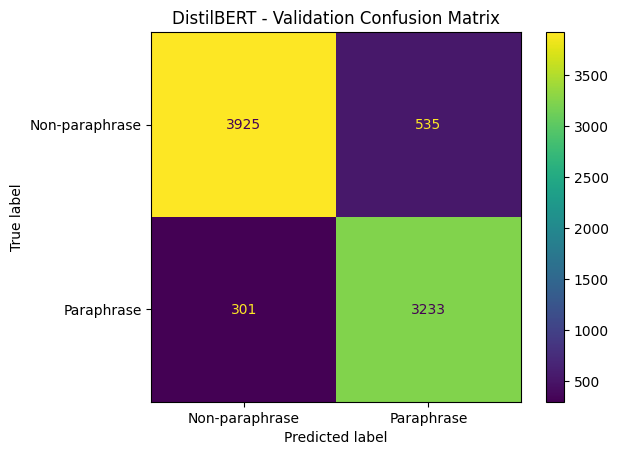

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_validation_true,
    y_validation_pred,
    display_labels=[
        "Non-paraphrase",
        "Paraphrase"
    ]
)

plt.title("DistilBERT - Validation Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_validation_true,
        y_validation_pred,
        target_names=[
            "Non-paraphrase",
            "Paraphrase"
        ]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.93      0.88      0.90      4460
    Paraphrase       0.86      0.91      0.89      3534

      accuracy                           0.90      7994
     macro avg       0.89      0.90      0.89      7994
  weighted avg       0.90      0.90      0.90      7994



The validation results show strong performance for both classes. The model has higher precision for non-paraphrases and higher recall for paraphrases.

The F1-scores are also similar for the two classes, which shows that the model performs well on both paraphrase and non-paraphrase examples.

## 11. Final Evaluation on the Test Set

The selected DistilBERT model is evaluated on the test set to measure its final performance on unseen data.

In [ ]:
test_output = final_trainer.predict(
    test_dataset
)

test_logits = test_output.predictions

y_test_pred = np.argmax(
    test_output.predictions,
    axis=1
)

y_test_true = clean_test_df[
    "label"
].to_numpy()

In [ ]:
test_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

test_precision = precision_score(
    y_test_true,
    y_test_pred
)

test_recall = recall_score(
    y_test_true,
    y_test_pred
)

test_f1 = f1_score(
    y_test_true,
    y_test_pred
)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.8844
Precision: 0.8453
Recall:    0.9034
F1-score:  0.8734


The test results are close to the validation results, with only a small decrease in the main metrics.

The model keeps a high recall for paraphrases and achieves an F1-score of 0.8734, which shows that it performs well on unseen data.

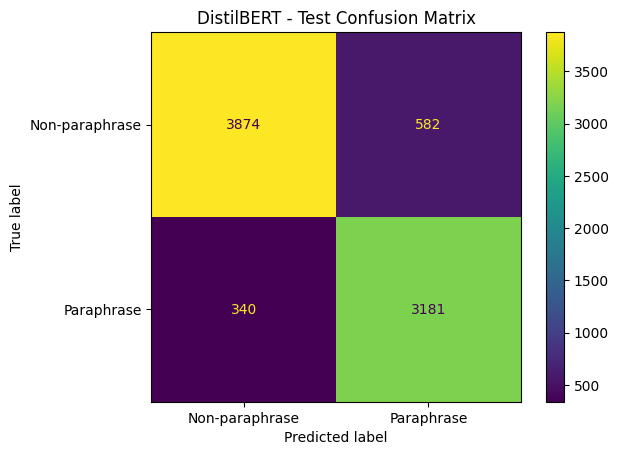

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_true,
    y_test_pred,
    display_labels=[
        "Non-paraphrase",
        "Paraphrase"
    ]
)

plt.title("DistilBERT - Test Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=[
            "Non-paraphrase",
            "Paraphrase"
        ]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.92      0.87      0.89      4456
    Paraphrase       0.85      0.90      0.87      3521

      accuracy                           0.88      7977
     macro avg       0.88      0.89      0.88      7977
  weighted avg       0.89      0.88      0.88      7977



In [ ]:
final_results = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],
    "Accuracy": [
        results_lr_2e5["eval_accuracy"],
        test_accuracy
    ],
    "Precision": [
        results_lr_2e5["eval_precision"],
        test_precision
    ],
    "Recall": [
        results_lr_2e5["eval_recall"],
        test_recall
    ],
    "F1-score": [
        results_lr_2e5["eval_f1"],
        test_f1
    ]
})

final_results.round(4)

,Dataset,Accuracy,Precision,Recall,F1-score
0,Validation,0.8954,0.8580,0.9148,0.8855
1,Test,0.8844,0.8453,0.9034,0.8734


The validation and test metrics stay at a similar level, which suggests that the model keeps its performance on new examples.

There is a small drop on the test set, but the overall results remain strong and balanced.

## 12. Exporting Test Predictions

The final test predictions are saved for the model comparison and error analysis.

In [ ]:
test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()[:, 1]

In [ ]:
distilbert_predictions_df = pd.DataFrame({
    "id": clean_test_df["id"].values,
    "sentence1": clean_test_df["sentence1"].values,
    "sentence2": clean_test_df["sentence2"].values,
    "y_true": y_test_true,
    "y_pred": y_test_pred,
    "paraphrase_probability": test_probabilities
})

distilbert_predictions_df.head()

,id,sentence1,sentence2,y_true,y_pred,paraphrase_probability
0,1,This was a series of nested angular standards ...,"This was a series of nested polar scales , so ...",0,0,0.000735
1,2,His father emigrated to Missouri in 1868 but r...,"His father emigrated to America in 1868 , but ...",0,0,0.000778
2,3,"In January 2011 , the Deputy Secretary General...","In January 2011 , FIBA Asia deputy secretary g...",1,1,0.992837
3,4,"Steiner argued that , in the right circumstanc...",Steiner held that the spiritual world can be r...,0,0,0.001481
4,5,"Luciano Williames Dias ( born July 25 , 1970 )...",Luciano Williames Dias ( born 25 July 1970 ) i...,0,0,0.001576


In [ ]:
os.makedirs("results", exist_ok=True)

distilbert_predictions_df.to_csv(
    "results/distilbert_test_predictions.csv",
    index=False
)

print("Saved rows:", len(distilbert_predictions_df))

Saved rows: 7977


## 13. Final Summary

The main findings from this notebook are:

- A pretrained DistilBERT model was fine-tuned for paraphrase detection.
- The model was trained using paired sentence inputs and evaluated with accuracy, precision, recall and F1-score.
- Three learning rates were compared, and 2e-5 achieved the best validation results.
- A higher weight decay was also tested, but it did not improve the model performance.
- The selected model achieved strong and balanced results on both the validation and test sets.
- The validation and test results remained at a similar level, suggesting consistent performance on unseen data.

Overall, DistilBERT performed considerably better than the traditional machine learning baseline and the Siamese BiLSTM model.